
Reading folder:
H:\FUBerlin\Measurements\UVvisNIR\CristianB\20260922_Cl2_and_Br2_samples_F008_F010
Loaded: 20260922_Baseline_1pcDOCD2O.txt
Loaded: 20260922_F008_Cl2@NI_d4.txt
Loaded: 20260922_F009_Cl2@P2_d3.txt
Loaded: 20260922_F010_Br2@P2_d3.txt
Loaded: 20260922_NI_d4.txt
Loaded: 20260922_P2_d4.txt
Could not load README.txt: Error tokenizing data. C error: Expected 1 fields in line 8, saw 2


Available spectra:
20260922_Baseline_1pcDOCD2O.txt
20260922_F008_Cl2@NI_d4.txt
20260922_F009_Cl2@P2_d3.txt
20260922_F010_Br2@P2_d3.txt
20260922_NI_d4.txt
20260922_P2_d4.txt


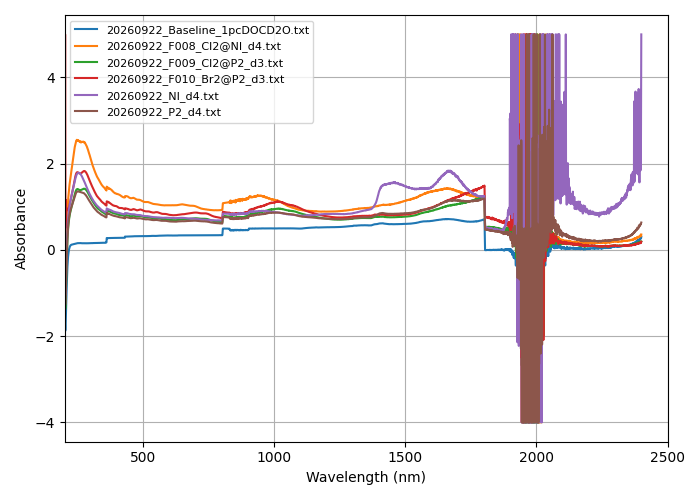


Corrected spectra:
20260922_P2_d4.txt
20260922_F009_Cl2@P2_d3.txt
20260922_F010_Br2@P2_d3.txt


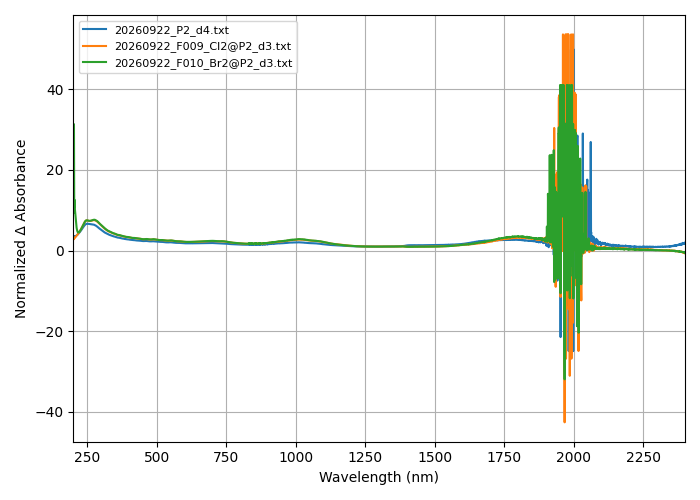

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib widget


# ==========================
# TXT DATA FOLDERS
# ==========================

txt_folders = [
    r"H:\FUBerlin\Measurements\UVvisNIR\CristianB\20260922_Cl2_and_Br2_samples_F008_F010",
]


# ==========================
# LOAD ALL TXT FILES
# ==========================

txt_spectra = {}


for txt_folder in txt_folders:

    print("\nReading folder:")
    print(txt_folder)

    for file in os.listdir(txt_folder):

        if not file.lower().endswith(".txt"):
            continue


        path = os.path.join(
            txt_folder,
            file
        )


        try:

            df = pd.read_csv(
                path,
                sep="\t",
                skiprows=1,
                dtype=str
            )


            df.columns = [
                "Wavelength",
                "Abs"
            ]


            # ------------------------------------------------
            # Clean strings
            # ------------------------------------------------

            df["Wavelength"] = (
                df["Wavelength"]
                .str.strip()
                .str.replace(
                    ",",
                    ".",
                    regex=False
                )
            )


            df["Abs"] = (
                df["Abs"]
                .str.strip()
                .str.replace(
                    ",",
                    ".",
                    regex=False
                )
            )


            # ------------------------------------------------
            # Convert to numbers
            # ------------------------------------------------

            df["Wavelength"] = pd.to_numeric(
                df["Wavelength"],
                errors="coerce"
            )


            df["Abs"] = pd.to_numeric(
                df["Abs"],
                errors="coerce"
            )


            # ------------------------------------------------
            # Remove empty rows
            # ------------------------------------------------

            df = df.dropna()


            # ------------------------------------------------
            # Sort by wavelength
            # ------------------------------------------------

            df = df.sort_values(
                "Wavelength"
            ).reset_index(
                drop=True
            )


            # ------------------------------------------------
            # Use folder + filename as unique key
            # ------------------------------------------------
            folder_name = os.path.basename(
                txt_folder
            )

            key = f"{folder_name}/{file}"

            txt_spectra[file] = df

            print(
                "Loaded:",
                file
             )


        except Exception as e:

            print(
                f"Could not load {file}: {e}"
            )



# ==========================
# AVAILABLE SPECTRA
# ==========================

print("\nAvailable spectra:")

for name in txt_spectra:
    print(name)




# ==========================
# PLOT RAW SPECTRA
# ==========================

plt.figure(figsize=(7,5))


for name, df in txt_spectra.items():

    plt.plot(
        df["Wavelength"],
        df["Abs"],
        label=name
    )


plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance")
plt.xlim(200,2500)
plt.grid(True)
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()





# ==========================
# NORMALIZATION FUNCTION
# ==========================


def NormalizeSpectra(
        spectra_input,
        xmin,
        xmax,
        mode="M"
):

    """
    Normalize spectra.

    mode:
        M -> normalize by maximum
        I -> normalize by integral
        V -> normalize by valley (minimum)
    """

    normalized = {}

    for name, df in spectra_input.items():

        df_norm = df.copy()

        X = df_norm["Wavelength"].values
        Y = df_norm["Abs"].values

        mask = (
            (X >= xmin)
            &
            (X <= xmax)
        )

        X_window = X[mask]
        Y_window = Y[mask]

        if len(X_window) == 0:

            print(
                "No normalization range:",
                name
            )

            continue

        if mode.upper() == "M":

            factor = np.max(
                Y_window
            )

        elif mode.upper() == "I":

            factor = np.trapezoid(
                Y_window,
                X_window
            )

        elif mode.upper() == "V":

            factor = np.min(
                Y_window
            )

        else:

            raise ValueError(
                "Mode must be 'M', 'I', or 'V'"
            )

        if factor != 0:

            df_norm["Abs"] = (
                Y / factor
            )

        normalized[name] = df_norm

    return normalized



# ==========================
# PLOT FUNCTION WITH OFFSET
# ==========================


def PlotSpectra(
        spectra_dict,
        spectra_names,
        offset_step=0.0,
        xmin=None,
        xmax=None,
        ylabel="Absorbance"
):


    plt.figure(figsize=(7,5))


    for i, name in enumerate(spectra_names):


        df = spectra_dict[name]


        X = df["Wavelength"].values
        Y = df["Abs"].values


        Y_plot = (
            Y
            +
            i * offset_step
        )


        plt.plot(
            X,
            Y_plot,
            label=name
        )



    plt.xlabel(
        "Wavelength (nm)"
    )


    plt.ylabel(
        ylabel
    )


    if xmin is not None or xmax is not None:

        plt.xlim(
            xmin,
            xmax
        )


    plt.grid(True)


    plt.legend(
        fontsize=8
    )


    plt.tight_layout()

    plt.show()




# ==========================
# SELECT SPECTRA
# ==========================


spectra_to_plot = [

#"20260922_Baseline_1pcDOCD2O.txt",
#"20260922_NI_d4.txt",
#"20260922_F008_Cl2@NI_d4.txt",

"20260922_P2_d4.txt",
"20260922_F009_Cl2@P2_d3.txt",
"20260922_F010_Br2@P2_d3.txt",
]



# ==========================
# BASELINE SUBTRACTION
# ==========================


baseline_name = "20260922_Baseline_1pcDOCD2O.txt"


baseline = txt_spectra[baseline_name]


corrected_spectra = {}



for name in spectra_to_plot:


    # Check that selected spectrum exists
    if name not in txt_spectra:

        print(
            f"WARNING: {name} not found in txt_spectra"
        )

        continue


    df = txt_spectra[name]


    corrected = pd.DataFrame()


    corrected["Wavelength"] = (
        df["Wavelength"]
    )


    corrected["Abs"] = (
        df["Abs"].values
        -
        baseline["Abs"].values
    )


    corrected_spectra[name] = corrected


print("\nCorrected spectra:")

for name in corrected_spectra:

    print(name)



# ==========================
# NORMALIZE
# ==========================

normalized_spectra = corrected_spectra
normalized_spectra = NormalizeSpectra(corrected_spectra,xmin=1230,xmax=1250,mode="V")


# ==========================
# PLOT NORMALIZED SPECTRA
# ==========================


PlotSpectra(
    normalized_spectra,
    spectra_to_plot,
    offset_step=0.0,
    xmin=200,
    xmax=2400,
    ylabel="Normalized Δ Absorbance"
)